# 🧠 02 - Entraînement du Modèle (Transfer Learning)

Utilisation de **MobileNetV2** avec Transfer Learning pour classifier 100 sports.

In [15]:
import os
import sys
sys.path.append('..')

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

from src.model import build_model
from src.data_preprocessing import get_data_generators
from src.utils import MODELS_DIR

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU disponible: []


In [14]:
pip install gdown --default-timeout=1000

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [gdown]
   ---------------------------------------- 2/2 [gdown]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install tensorflow --default-timeout=1000

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import tensorflow as tf
print(f"Version de TensorFlow : {tf.__version__}")
print(f"Version de Python : {sys.version}")

Version de TensorFlow : 2.21.0
Version de Python : 3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


## 1. Chargement des données

In [16]:
train_gen, valid_gen, test_gen = get_data_generators()

print(f"Classes: {train_gen.num_classes}")
print(f"Train batches: {train_gen.samples}")
print(f"Valid batches: {valid_gen.samples}")
print(f"Test batches: {test_gen.samples}")

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Classes: 100
Train batches: 13492
Valid batches: 500
Test batches: 500


## 2. Construction du modèle

In [17]:
model = build_model(num_classes=100, img_size=224)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 35s 4us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Callbacks

In [18]:
os.makedirs(MODELS_DIR, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, 'best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

## 4. Entraînement (Phase 1 : base frozen)

In [21]:
EPOCHS_PHASE1 = 2

history1 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.7662 - loss: 0.8000
Epoch 1: val_accuracy improved from 0.87400 to 0.88600, saving model to c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras

Epoch 1: finished saving model to c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 406s 962ms/step - accuracy: 0.7584 - loss: 0.8165 - val_accuracy: 0.8860 - val_loss: 0.3668 - learning_rate: 0.0010
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.7730 - loss: 0.7893
Epoch 2: val_accuracy did not improve from 0.88600
422/422 ━━━━━━━━━━━━━━━━━━━━ 416s 985ms/step - accuracy: 0.7645 - loss: 0.8066 - val_accuracy: 0.8860 - val_loss: 0.3805 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


## 5. Fine-tuning (Phase 2 : défreeze partiel)

In [24]:
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} ({layer.__class__.__name__})")

0: input_layer (InputLayer)
1: Conv1 (Conv2D)
2: bn_Conv1 (BatchNormalization)
3: Conv1_relu (ReLU)
4: expanded_conv_depthwise (DepthwiseConv2D)
5: expanded_conv_depthwise_BN (BatchNormalization)
6: expanded_conv_depthwise_relu (ReLU)
7: expanded_conv_project (Conv2D)
8: expanded_conv_project_BN (BatchNormalization)
9: block_1_expand (Conv2D)
10: block_1_expand_BN (BatchNormalization)
11: block_1_expand_relu (ReLU)
12: block_1_pad (ZeroPadding2D)
13: block_1_depthwise (DepthwiseConv2D)
14: block_1_depthwise_BN (BatchNormalization)
15: block_1_depthwise_relu (ReLU)
16: block_1_project (Conv2D)
17: block_1_project_BN (BatchNormalization)
18: block_2_expand (Conv2D)
19: block_2_expand_BN (BatchNormalization)
20: block_2_expand_relu (ReLU)
21: block_2_depthwise (DepthwiseConv2D)
22: block_2_depthwise_BN (BatchNormalization)
23: block_2_depthwise_relu (ReLU)
24: block_2_project (Conv2D)
25: block_2_project_BN (BatchNormalization)
26: block_2_add (Add)
27: block_3_expand (Conv2D)
28: block_3

In [26]:
# 1. On rend l'ensemble du modèle entraînable
model.trainable = True

# 2. On définit le point de coupure (159 - 30 = 129)
# Les couches de 0 à 128 seront gelées, de 129 à 158 seront entraînables
cutoff = len(model.layers) - 30

for layer in model.layers[:cutoff]:
    layer.trainable = False

# 3. Vérification
print(f"Nombre total de couches : {len(model.layers)}")
print(f"Dernière couche gelée : {model.layers[cutoff-1].name}")
print(f"Première couche dégelée : {model.layers[cutoff].name}")

# 4. RECOMPILATION OBLIGATOIRE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # LR très bas pour le fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Nombre total de couches : 159
Dernière couche gelée : block_14_depthwise
Première couche dégelée : block_14_depthwise_BN


In [27]:
# 1. On rend tout le modèle entraînable
model.trainable = True

# 2. On gèle tout sauf les 30 dernières couches (Logique adaptée à ton modèle plat)
cutoff = len(model.layers) - 30
for layer in model.layers[:cutoff]:
    layer.trainable = False

# 3. On recompile avec le Learning Rate faible pour le Fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. On lance l'entraînement (Phase 2)
EPOCHS_PHASE2 = 2

history2 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.7785 - loss: 0.7329
Epoch 1: val_accuracy improved from 0.88600 to 0.89600, saving model to c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras

Epoch 1: finished saving model to c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 414s 966ms/step - accuracy: 0.7768 - loss: 0.7403 - val_accuracy: 0.8960 - val_loss: 0.3443 - learning_rate: 1.0000e-05
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.7888 - loss: 0.6988
Epoch 2: val_accuracy improved from 0.89600 to 0.90000, saving model to c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras

Epoch 2: finished saving model to c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 402s 952ms/step - accuracy: 0.7915 - loss: 0.6891 - val_accuracy: 0.9000 - val_loss: 0.3348 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best e

## 6. Visualisation des courbes

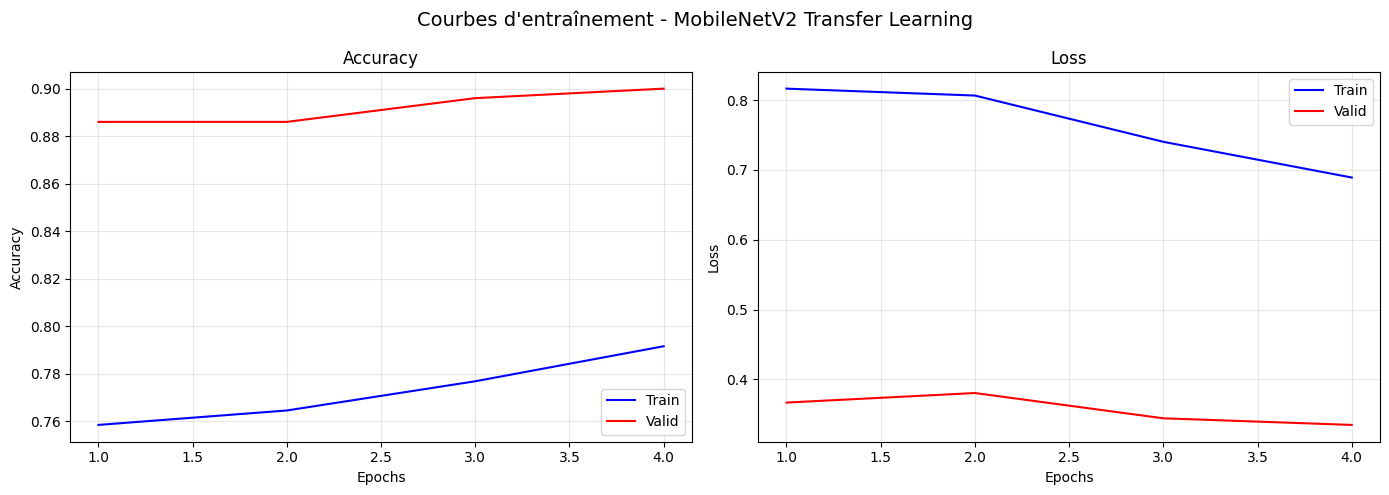

In [28]:
# Combiner les historiques
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_range, acc, 'b', label='Train')
ax1.plot(epochs_range, val_acc, 'r', label='Valid')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_range, loss, 'b', label='Train')
ax2.plot(epochs_range, val_loss, 'r', label='Valid')
ax2.set_title('Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'entraînement - MobileNetV2 Transfer Learning', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Évaluation sur le test set

In [29]:
# Charger le meilleur modèle
best_model = load_model(os.path.join(MODELS_DIR, 'best_model.keras'))

test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 643ms/step - accuracy: 0.9300 - loss: 0.2464

Test Accuracy: 0.9300
Test Loss: 0.2464


In [31]:
# Version simplifiée pour local
import tensorflow as tf
import os

# Chemin vers ton .keras
input_path = "best_model.keras"  # ← modifie si besoin
output_path = "best_model.h5"

# Charge
model = tf.keras.models.load_model(input_path)
print(f"✅ Chargé : {input_path}")

# Sauvegarde en h5
model.save(output_path, save_format='h5')
print(f"✅ Converti : {output_path}")
print(f"📊 Taille : {os.path.getsize(output_path)/1024/1024:.1f} MB")

# Vérifie
test = tf.keras.models.load_model(output_path)
print("✅ Le .h5 est valide")

ValueError: File not found: filepath=best_model.keras. Please ensure the file is an accessible `.keras` zip file.

## 8. Sauvegarde finale

Le modèle est sauvegardé dans `models/best_model.keras`.

**Prochaines étapes :**
1. Uploader le modèle sur Google Drive
2. Copier le lien dans `src/model.py` (MODEL_DRIVE_URL)
3. Tester l'application Streamlit : `streamlit run app/streamlit_app.py`

In [32]:
## 8. Sauvegarde finale (compatible TF 2.10)

import os
from tensorflow.keras.models import load_model
from src.utils import MODELS_DIR

# 1. Charge le meilleur modèle (celui sauvegardé par ModelCheckpoint)
best_model = load_model(os.path.join(MODELS_DIR, 'best_model.keras'))

# 2. Évalue sur le test set (optionnel, pour confirmer)
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 3. SAUVEGARDE EN .h5 (format compatible partout)
h5_path = os.path.join(MODELS_DIR, 'best_model.h5')
best_model.save(h5_path, save_format='h5')
print(f"\n✅ Modèle sauvegardé en .h5 : {h5_path}")

# 4. Vérification
h5_size = os.path.getsize(h5_path)
print(f"📊 Taille : {h5_size / 1024 / 1024:.2f} MB")

# Vérifie la signature HDF5
with open(h5_path, 'rb') as f:
    header = f.read(8)
if header[:8] == b'\x89HDF\r\n\x1a\n':
    print("✅ Signature HDF5 confirmée")
else:
    print("⚠️ Problème de format")

# 5. Test de rechargement
model_test = load_model(h5_path)
print("✅ Le .h5 se recharge correctement")

# 6. Compare les prédictions (sanity check)
import numpy as np
dummy = np.zeros((1, 224, 224, 3))
pred1 = best_model.predict(dummy, verbose=0)
pred2 = model_test.predict(dummy, verbose=0)
if np.allclose(pred1, pred2):
    print("✅ Prédictions identiques")
else:
    print("⚠️ Différences détectées")

print("\n" + "="*50)
print("🎉 FICHIER best_model.h5 PRÊT")
print("="*50)
print(f"\n📁 Localisation : {os.path.abspath(h5_path)}")
print(f"\n👉 Prochaines étapes :")
print("   1. Upload best_model.h5 sur Google Drive")
print("   2. Rends-le public (Partager → Tous ceux qui ont le lien)")
print("   3. Copie l'ID du lien dans src/model.py")
print("\n📋 URL à mettre dans MODEL_DRIVE_URL :")
print("   https://drive.google.com/uc?id=TON_ID&export=download&confirm=t")
print("\n📝 Exemple d'ID : 1xG2mIfFIhg607MdF-lTGIMif14L3fKK8")

16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 729ms/step - accuracy: 0.9300 - loss: 0.2464



Test Accuracy: 0.9300
Test Loss: 0.2464

✅ Modèle sauvegardé en .h5 : c:\Users\gongue\Desktop\sports-classifier\models\best_model.h5
📊 Taille : 17.23 MB
✅ Signature HDF5 confirmée


✅ Le .h5 se recharge correctement
✅ Prédictions identiques

🎉 FICHIER best_model.h5 PRÊT

📁 Localisation : c:\Users\gongue\Desktop\sports-classifier\models\best_model.h5

👉 Prochaines étapes :
   1. Upload best_model.h5 sur Google Drive
   2. Rends-le public (Partager → Tous ceux qui ont le lien)
   3. Copie l'ID du lien dans src/model.py

📋 URL à mettre dans MODEL_DRIVE_URL :
   https://drive.google.com/uc?id=TON_ID&export=download&confirm=t

📝 Exemple d'ID : 1xG2mIfFIhg607MdF-lTGIMif14L3fKK8


In [34]:
# Conversion rapide .keras → .h5 (si tu as déjà best_model.keras)

import os
from tensorflow.keras.models import load_model
from src.utils import MODELS_DIR

keras_path = os.path.join(MODELS_DIR, 'best_model.keras')
h5_path = os.path.join(MODELS_DIR, 'best_model.h5')

print(f"Chargement de {keras_path}...")
model = load_model(keras_path)
print("✅ Modèle chargé")

print(f"\nSauvegarde en {h5_path}...")
model.save(h5_path, save_format='h5')
print("✅ Conversion terminée")

# Vérifie
size = os.path.getsize(h5_path)
print(f"\n📊 Taille .h5 : {size / 1024 / 1024:.2f} MB")
print(f"\n📁 Fichier créé : {os.path.abspath(h5_path)}")


Chargement de c:\Users\gongue\Desktop\sports-classifier\models\best_model.keras...


✅ Modèle chargé

Sauvegarde en c:\Users\gongue\Desktop\sports-classifier\models\best_model.h5...
✅ Conversion terminée

📊 Taille .h5 : 17.23 MB

📁 Fichier créé : c:\Users\gongue\Desktop\sports-classifier\models\best_model.h5


In [36]:
MODEL_DRIVE_URL = "https://drive.google.com/uc?id=TON_NOUVEL_ID&export=download&confirm=t"
MODEL_PATH = os.path.join(MODELS_DIR, "best_model.h5")  # ← .h5 ici